# Part 5a - Final pipeline

Skipping non-image file: MMU-Iris-Database\ReadMe.txt
Skipping non-image file: MMU-Iris-Database\1\left\Thumbs.db
Skipping non-image file: MMU-Iris-Database\1\right\Thumbs.db
Skipping non-image file: MMU-Iris-Database\10\left\Thumbs.db
Skipping non-image file: MMU-Iris-Database\37\left\Thumbs.db
Skipping non-image file: MMU-Iris-Database\42\left\Thumbs.db
Skipping non-image file: MMU-Iris-Database\46\left\Thumbs.db
Skipping non-image file: MMU-Iris-Database\7\left\Thumbs.db
Image 0: final threshold P/X = 8.98 (factor X = 4.35), white ratio = 0.975
Image 1: final threshold P/X = 11.31 (factor X = 3.90), white ratio = 0.975
Image 2: final threshold P/X = 11.76 (factor X = 3.85), white ratio = 0.975
Image 3: final threshold P/X = 9.49 (factor X = 4.35), white ratio = 0.975
Image 0: final threshold P/X = 99.26 (factor X = 1.35), white ratio = 0.748
Image 1: final threshold P/X = 108.19 (factor X = 1.30), white ratio = 0.733
Image 2: final threshold P/X = 130.52 (factor X = 1.20), white rat

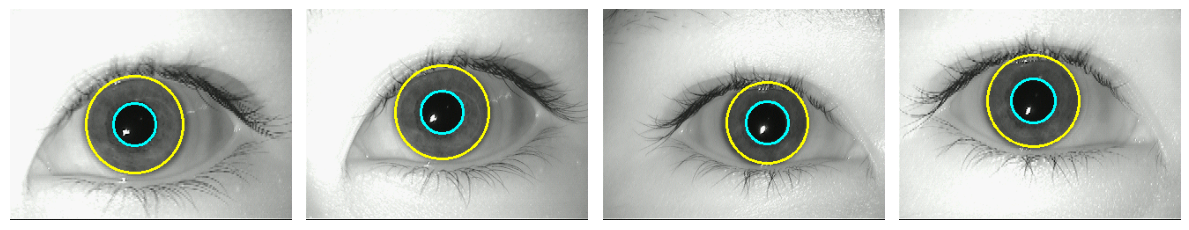

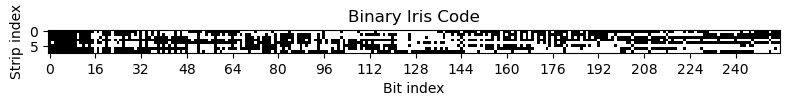

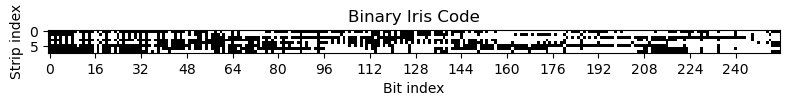

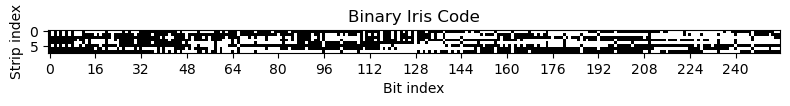

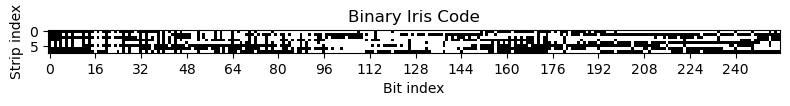

In [49]:
######################################################################
# Libraries ##########################################################
######################################################################

import os
import random
import re
from collections import Counter

import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import cv2
from PIL import Image

######################################################################
# Fucntions ##########################################################
######################################################################

# Loading and preview ------------------------------------------------

def load_images_ending_with_pattern(folder_path, regex):
    images = []
    pattern = re.compile(regex)

    for root, _, files in os.walk(folder_path):
        for file in files:
            if not pattern.match(file):
                continue
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()
                image = cv2.imread(file_path, cv2.IMREAD_COLOR)
                if image is not None:
                    images.append(image)
            except Exception:
                print(f"Skipping non-image file: {file_path}")
    return images

def preview_images(images, num_previews=5):
    if not images:
        print("No images to display.")
        return

    num_previews = min(num_previews, len(images))
    selected_images = images[:num_previews]
    
    cols = min(15, num_previews)
    rows = math.ceil(num_previews / 15)
    
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, img in enumerate(selected_images):
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Resizing -----------------------------------------------------------

def resize_images(images, max_size=256):
    resized = []
    for img in images:
        h, w = img.shape[:2]
        scale = max_size / max(h, w)
        new_size = (int(w * scale), int(h * scale))  # (width, height)
        resized_img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)
        resized.append(resized_img)
    return resized

# Correcting poor quality image --------------------------------------

def remove_tophat_glints(gray):
    r = max(3, int(min(gray.shape)*0.02) // 2 * 2 + 1)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (r, r))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    return cv2.subtract(gray, tophat)
    
def inpaint_highlights(gray):
    _, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.dilate(mask, kernel, iterations=2)
    inpainted = cv2.inpaint(gray, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    return inpainted
    
def preprocess_remove_glares(gray):
    gray = remove_tophat_glints(gray)
    gray = cv2.GaussianBlur(gray, (7, 7), sigmaX=1.5)
    gray = inpaint_highlights(gray)
    return gray

# Greyscale ----------------------------------------------------------

def convert_images_to_greyscale(images):
    grey_images = []
    for img in images:
        if len(img.shape) == 3:
            grey_img = np.mean(img, axis=2).astype(img.dtype)
        else:
            grey_img = img.copy()
        grey_images.append(grey_img)
    return grey_images

# Binarization -------------------------------------------------------

def adaptive_binarize(
    grey_images,
    initial_factor,
    white_ratio_thresh=0.9,
    min_factor=1.0,
    factor_step=0.5,
    verbose=False
):
    binaries = []

    for idx, grey in enumerate(grey_images):
        X = initial_factor
        while True:

            #------------------------------------------
            # Image sizes
            h, w = grey.shape
            # Treshold based on mean
            P = np.sum(grey) / (h * w)
            # Modified treshold
            P = P / X
            # Binarization
            bin_image = np.zeros_like(grey, dtype=np.uint8)
            bin_image[grey >= P] = 255
            #------------------------------------------

            white_ratio = np.mean(bin_image == 255)
            if white_ratio > white_ratio_thresh and (X - factor_step) >= min_factor:
                new_X = round(X - factor_step, 2)
                if verbose:
                    print(
                        f"Image {idx}: white ratio {white_ratio:.3f} > {white_ratio_thresh}, "
                        f"lowering factor {X:.2f} → {new_X:.2f} and retrying"
                    )
                X = new_X
                continue
            break

        # Print final threshold if not verbose
        if not verbose:
            print(
                f"Image {idx}: final threshold P/X = {P/X:.2f} (factor X = {X:.2f}), "
                f"white ratio = {white_ratio:.3f}"
            )

        binaries.append(bin_image)

    return binaries

# Morphologial operations --------------------------------------------

def get_structuring_element(shape, ksize, anchor=None):
    rows, cols = ksize
    if anchor is None:
        anchor = (rows // 2, cols // 2)
    if shape.lower() == "rect":
        kernel = np.ones((rows, cols), dtype=np.uint8)
    elif shape.lower() == "ellipse":
        kernel = np.zeros((rows, cols), dtype=np.uint8)
        # Use the center of the kernel for ellipse definition.
        cy, cx = rows // 2, cols // 2  
        a = rows / 2.0
        b = cols / 2.0
        for i in range(rows):
            for j in range(cols):
                # Equation of ellipse centered at (cy, cx)
                if ((i - cy) / a)**2 + ((j - cx) / b)**2 <= 1:
                    kernel[i, j] = 1
    elif shape.lower() == "cross":
        kernel = np.zeros((rows, cols), dtype=np.uint8)
        # Place ones in the row and column corresponding to anchor
        ay, ax = anchor
        if 0 <= ay < rows:
            kernel[ay, :] = 1
        if 0 <= ax < cols:
            kernel[:, ax] = 1
    else:
        raise ValueError("Unsupported kernel shape. Choose 'rect', 'ellipse', or 'cross'.")
    return kernel, anchor

def erosion(image, kernel, anchor):
    krows, kcols = kernel.shape
    ay, ax = anchor
    pad_top = ay
    pad_bottom = krows - ay - 1
    pad_left = ax
    pad_right = kcols - ax - 1
    padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=image.min())
    out = np.zeros_like(image)
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+krows, j:j+kcols]
            out[i, j] = np.max(region[kernel==1])
    return out

def dilation(image, kernel, anchor):
    krows, kcols = kernel.shape
    ay, ax = anchor
    pad_top = ay
    pad_bottom = krows - ay - 1
    pad_left = ax
    pad_right = kcols - ax - 1
    padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=image.max())
    out = np.zeros_like(image)
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+krows, j:j+kcols]
            out[i, j] = np.min(region[kernel==1])
    return out

def opening(image, kernel, anchor):
    eroded = erosion(image, kernel, anchor)
    opened = dilation(eroded, kernel, anchor)
    return opened

def closing(image, kernel, anchor):
    dilated = dilation(image, kernel, anchor)
    closed = erosion(dilated, kernel, anchor)
    return closed

# Remove artifacts away from center ----------------------------------

def mask_outside_boundary(images, x_thresh=0.9, y_thresh=0.9):
    masked = []
    for img in images:
        h, w = img.shape[:2]
        cx, cy = w/2.0, h/2.0
        dx, dy = x_thresh*(w/2.0), y_thresh*(h/2.0)
        left, right   = cx - dx, cx + dx
        top, bottom   = cy - dy, cy + dy

        # Create a boolean mask of pixels to white‑out:
        ys, xs = np.ogrid[:h, :w]
        outside = (xs < left) | (xs > right) | (ys < top) | (ys > bottom)

        out = img.copy()
        if img.ndim == 2:
            out[outside] = 255
        else:
            out[outside] = (255, 255, 255)
        masked.append(out)
    return masked

# Projections and find center ----------------------------------------

def compute_projections(image):
    h, w = image.shape
    # horizontal & vertical
    h_proj = np.sum(image == 0, axis=1)
    v_proj = np.sum(image == 0, axis=0)

    # main diagonal offsets d = j - i
    d_off = np.arange(-h+1, w)
    d_proj = np.array([
        sum(image[i, i + d] == 0
            for i in range(max(0, -d), min(h, w - d)))
        for d in d_off
    ])

    # anti-diagonal offsets s = i + j
    ad_off = np.arange(0, h + w - 1)
    ad_proj = np.array([
        sum(image[i, s - i] == 0
            for i in range(max(0, s - (w - 1)), min(h, s + 1)))
        for s in ad_off
    ])

    return h_proj, v_proj, d_proj, ad_proj, d_off, ad_off

def get_pupil_centers_from_projections(pupil_projections):
    centers = []

    for (h_proj, v_proj, d_proj, ad_proj, d_off, ad_off) in pupil_projections:
        h = h_proj.shape[0]
        w = v_proj.shape[0]

        # 1) indices of max in each projection
        h_maxs  = np.flatnonzero(h_proj  == h_proj.max())   # y‑coords
        v_maxs  = np.flatnonzero(v_proj  == v_proj.max())   # x‑coords
        d_idxs  = np.flatnonzero(d_proj  == d_proj.max())
        ad_idxs = np.flatnonzero(ad_proj == ad_proj.max())
        d_maxs  = d_off[d_idxs]    # j - i = d
        ad_maxs = ad_off[ad_idxs]  # i + j = s

        pts = []
        # H and V
        for y in h_maxs:
            for x in v_maxs:
                pts.append((x, y))

        # H and D:  j = i + d  → x = y + d
        for y in h_maxs:
            for d in d_maxs:
                pts.append((y + d, y))

        # H and A:  i + j = s → x = s - y
        for y in h_maxs:
            for s in ad_maxs:
                pts.append((s - y, y))

        # V and D:  x = x, y = x - d
        for x in v_maxs:
            for d in d_maxs:
                pts.append((x, x - d))

        # V and A:  x = x, y = s - x
        for x in v_maxs:
            for s in ad_maxs:
                pts.append((x, s - x))

        # D and A:  j = i + d  and  i + j = s
        # -> i = (s - d)/2,  j = i + d
        for d in d_maxs:
            for s in ad_maxs:
                i = (s - d) / 2.0
                j = i + d
                pts.append((j, i))

        # filter to valid image coords
        valid = [(x, y) for x, y in pts if 0 <= x < w and 0 <= y < h]
        if not valid:
            centers.append((None, None))
        else:
            xs, ys = zip(*valid)
            centers.append((float(np.mean(xs)), float(np.mean(ys))))

    return centers

# Find pupil radious -------------------------------------------------

def find_radius_from_projection_edges(projections, centers):
    radii = []

    for (h_proj, v_proj, d_proj, ad_proj, d_off, ad_off), _ in zip(projections, centers):
        # Horizontal (rows) → y direction
        h_indices = np.where(h_proj > 0)[0]
        h_radius = (h_indices[-1] - h_indices[0] + 1) / 2.0 if len(h_indices) > 0 else 0

        # Vertical (columns) → x direction
        v_indices = np.where(v_proj > 0)[0]
        v_radius = (v_indices[-1] - v_indices[0] + 1) / 2.0 if len(v_indices) > 0 else 0

        # Diagonal
        d_indices = np.where(d_proj > 0)[0]
        d_radius = (d_indices[-1] - d_indices[0] + 1) / 2.0 / math.sqrt(2) if len(d_indices) > 0 else 0

        # Anti-diagonal
        ad_indices = np.where(ad_proj > 0)[0]
        ad_radius = (ad_indices[-1] - ad_indices[0] + 1) / 2.0 / math.sqrt(2) if len(ad_indices) > 0 else 0

        radius = np.mean([v_radius, h_radius, d_radius, ad_radius])
        radii.append(radius)

    return radii

# Find iris radious --------------------------------------------------

def find_iris_boundaries(
    grey_images, centers, radii, iris_masks,
    num_strips=10, max_frac=2.0, start_index=1
):
    iris_radii = []

    for img, (cx_f, cy_f), rp, mask in zip(grey_images, centers, radii, iris_masks):
        cx, cy = cx_f, cy_f
        # build ring edges
        edges = np.linspace(rp, rp * max_frac, num_strips + 1)
        h, w = img.shape
        Y, X = np.ogrid[:h, :w]
        D = np.sqrt((X - cx)**2 + (Y - cy)**2)

        # compute mean brightness per ring
        means = []
        for k in range(1, num_strips + 1):
            inner, outer = edges[k-1], edges[k]
            ring_mask = (D >= inner) & (D < outer) & (mask == 0)
            vals = img[ring_mask]
            means.append(vals.mean() if vals.size else 0)

        # derivative between adjacent means
        deriv = np.diff(means)
        if deriv.size == 0:
            iris_radii.append(None)
            continue

        # pick the largest jump
        idx = int(np.argmax(deriv[start_index:]) + 1)
        # boundary is at edges[idx+1]
        iris_radii.append(float(edges[idx+1]))

    return iris_radii

# Transfer centers to different size ---------------------------------

def map_center_to_different_image(center, target_shape, source_shape):
    src_h, src_w = source_shape
    tgt_h, tgt_w = target_shape

    x, y = center

    # Compute scaling factors regardless of direction
    scale_x = tgt_w / src_w
    scale_y = tgt_h / src_h

    # Scale and round to integer pixel location
    x_new = int(round(x * scale_x))
    y_new = int(round(y * scale_y))

    return (x_new, y_new)

def map_radius_to_different_image(radius, new_shape, base_shape):
    base_h, base_w = base_shape
    new_h, new_w = new_shape

    # Scale based on average scaling factor from both dimensions
    scale_h = new_h / base_h
    scale_w = new_w / base_w
    scale = (scale_h + scale_w) / 2.0

    return radius * scale

# Get iris code ------------------------------------------------------

def get_raw_strips(
    images,
    binarized_iris_images,
    centers,
    pupil_radii,
    iris_radii,
    num_stripes=8,
    angular_res=360
):

    all_strips = []
    for img, mask, (cx, cy), rp, ri in zip(
        images, binarized_iris_images, centers, pupil_radii, iris_radii
    ):

        h, w = img.shape[:2]
        Y, X = np.ogrid[:h, :w]
        D = np.sqrt((X - cx)**2 + (Y - cy)**2)
        A = (np.degrees(np.arctan2(Y - cy, X - cx)) + 360) % 360
        A = (A - 270) % 360
        edges = np.linspace(rp, ri, num_stripes + 1)

        strips = []
        polar_size = (angular_res, int(ri))   # (width, max radius)
        origin     = (int(cx), int(cy))
        maxR       = float(ri)
        for i in range(num_stripes):
            inner, outer = edges[i], edges[i+1]
            radial_mask = (D >= inner) & (D < outer) #& (mask == 0)

            # define angular mask per stripe
            if i < 4:
                ang_mask = ((A >= 15) & (A <= 360-15))
            elif i < 6:
                ang_mask = (A >= 90-56.5) & (A <= 90+56.5) | (A >= 270-56.5) & (A <= 270+56.5)
            elif i < 8:
                ang_mask = (A >= 90-45) & (A <= 90+45) | (A >= 270-45) & (A <= 270+45)
            strip_mask = radial_mask & ang_mask

            # --- manual unwarp to rectangular strip ---
            radial_steps = int(np.ceil(outer - inner))
            angles       = np.linspace(0, 2*np.pi, angular_res, endpoint=False)
            angles = (angles + 3 * np.pi / 2) % (2 * np.pi)
            radii        = inner + np.linspace(0, outer-inner, radial_steps, endpoint=False)

            R, Theta = np.meshgrid(radii, angles, indexing='ij')
            Xs = np.clip((cx + R * np.cos(Theta)).astype(int), 0, w-1)
            Ys = np.clip((cy + R * np.sin(Theta)).astype(int), 0, h-1)

            strip_vals = img[Ys, Xs]
            mask_vals  = strip_mask[Ys, Xs]

            strip_vals[~mask_vals] = 0

            valid_cols = mask_vals.any(axis=0)
            strip_rect = strip_vals[:, valid_cols]

            strips.append(strip_rect)

        all_strips.append(strips)

    return all_strips

def collapse_strips(raw_strips, sigma=None):
    collapsed = []
    for strip in raw_strips:
        H, W = strip.shape[:2]
        C = strip.shape[2] if strip.ndim == 3 else 1

        # 1) Konwersja do szarości
        gray = strip[...,0]

        # 2) budujemy okno Gaussa dla wysokości H
        if sigma is None:
            sigma = H/6.0
        coords = np.arange(H)
        center = (H - 1)/2.0
        gauss = np.exp(-0.5 * ((coords - center)/sigma)**2)
        gauss /= gauss.sum()   # znormalizuj tak, żeby suma wag = 1

        # 3) ważone uśrednienie każdej kolumny
        #    wynik to wektor [0..W-1]
        col_avg = gauss @ gray   # shape: (W,)
        collapsed.append(col_avg)

    return collapsed

def gabor_decompose(strips, f, num_coeffs=128):
    """
    strips       : list of 1D numpy arrays, waried length
    f            : frequency of wave (in pixel cycles)
    num_coeffs   : number of coefficients

    Schema:
      - sigma = 0.5 * pi * f
      - center of waves: x_k = k * (1/f)
      - for every wave g_k(n) = exp( - (n−x_k)^2 / (2 sigma^2) ) * exp( 1j·2pif·(n−x_k) )
      - coefficients: c_k = sum_n strip[n] · g_k(n)
    """
    sigma = 0.5 * np.pi * f
    coeffs = np.zeros((len(strips), num_coeffs), dtype=np.complex128)

    for i, strip in enumerate(strips):
        W = strip.shape[0]
        n = np.arange(W)
        step = 1.0 / f
        x_k = np.arange(num_coeffs) * step

        delta = n[None, :] - x_k[:, None]
        gauss = np.exp(-0.5 * (delta / sigma)**2)
        osc   = np.exp(1j * 2 * np.pi * f * delta)

        G = gauss * osc
        coeffs[i, :] = G.dot(strip)

    return coeffs

def encode_phases(coeffs):
    """
    coeffs : numpy array of complex numbers, shape (num_strips, num_coeffs)

    Returns a tuple:
      - codes     : numpy array of dtype 'U1', shape (num_strips, num_coeffs, 2)
                    each entry is ['b0', 'b1'] corresponding to the phase quadrant
      - bitstring : str of length num_strips * num_coeffs * 2,
                    bits in order: strip0_coeff0_b0, strip0_coeff0_b1, strip0_coeff1_b0, strip0_coeff1_b1, ...

    Phase encoding:
      Quadrant I   (Re ≥ 0, Im ≥ 0) -> "00"
      Quadrant II  (Re <  0, Im ≥ 0) -> "01"
      Quadrant III (Re <  0, Im <  0) -> "11"
      Quadrant IV  (Re ≥ 0, Im <  0) -> "10"
    """
    re = coeffs.real
    im = coeffs.imag
    num_strips, num_coeffs = coeffs.shape

    codes = np.empty((num_strips, num_coeffs, 2), dtype='U1')

    # I Quadrant
    mask = (re >= 0) & (im >= 0)
    codes[mask, 0] = '0'
    codes[mask, 1] = '0'

    # II Quadrant
    mask = (re < 0) & (im >= 0)
    codes[mask, 0] = '0'
    codes[mask, 1] = '1'

    # III Quadrant
    mask = (re < 0) & (im < 0)
    codes[mask, 0] = '1'
    codes[mask, 1] = '1'

    # IV Quadrant
    mask = (re >= 0) & (im < 0)
    codes[mask, 0] = '1'
    codes[mask, 1] = '0'

    flat = codes.reshape(-1, 2)
    bitstring = ''.join(flat.flatten())

    return codes, bitstring

# Showcase -----------------------------------------------------------

def draw_pupil_and_iris_boundaries(images, centers, pupil_radii, iris_radii,
                                    pupil_color=(255, 255, 0), iris_color=(0, 255, 255), thickness=2):
    n = len(images)
    cols = min(5, n)
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 3, rows * 3))
    for i, (img, (cx, cy), rp, ri) in enumerate(zip(images, centers, pupil_radii, iris_radii)):
        disp = img.copy()
        if disp.ndim == 2:
            disp = cv2.cvtColor(disp, cv2.COLOR_GRAY2BGR)
        cv2.circle(disp, (int(round(cx)), int(round(cy))), int(round(rp)), pupil_color, thickness)
        cv2.circle(disp, (int(round(cx)), int(round(cy))), int(round(ri)), iris_color, thickness)

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB))
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def plot_resized_stripes(stripes, target_shape):
    H_t, W_t = target_shape[:2]

    resized = []
    for s in stripes:
        # If grayscale but target has 3 channels, convert; vice versa
        if s.ndim == 2 and len(target_shape) == 3:
            s = cv2.cvtColor(s, cv2.COLOR_GRAY2BGR)
        elif s.ndim == 3 and len(target_shape) == 2:
            s = cv2.cvtColor(s, cv2.COLOR_BGR2GRAY)
        resized.append(cv2.resize(s, (W_t, H_t), interpolation=cv2.INTER_LINEAR))

    fig, axes = plt.subplots(8, 1, figsize=(12, 6))
    axes = axes.flatten()
    for idx, (ax, img) in enumerate(zip(axes, resized)):
        if img.ndim == 2:
            ax.imshow(img, cmap='gray', aspect='auto')
        else:
            ax.imshow(img[..., ::-1], aspect='auto')  # BGR→RGB
        ax.axis('off')
    fig.subplots_adjust(hspace=0)
    plt.tight_layout(pad=1)
    plt.show()

def plot_bitstring(bitstring, num_strips=8, num_coeffs=128):
    bits = np.fromiter((int(c) for c in bitstring), dtype=int, count=len(bitstring))
    bit_image = bits.reshape(num_strips, num_coeffs*2)

    plt.figure(figsize=(8, 2.5))
    plt.imshow(bit_image, cmap='gray', aspect='equal', interpolation='nearest')
    plt.xlabel('Bit index')
    plt.ylabel('Strip index')
    plt.title('Binary Iris Code')
    plt.xticks(np.arange(0, num_coeffs*2, 16))
    plt.grid(False)
    plt.tight_layout()
    plt.show()

def hamming_distance(bitstring1, bitstring2):
    return sum(b1 != b2 for b1, b2 in zip(bitstring1, bitstring2))

######################################################################
# Pipeline ##########################################################
######################################################################

# Parameters
data_path = 'MMU-Iris-Database'
regex = r'.*'
max_image_size_for_processing = 256
white_ratio_threshold_for_pupils = 0.975
closing_kernel_size_for_pupils = 10
openening_kernel_size_for_pupils = 10
crop_x_axis_for_pupils = 0.75
crop_y_axis_for_pupils = 0.75
crop_x_axis_for_irises = 1.0
crop_y_axis_for_irises = 0.75
white_ratio_threshold_for_irises = 0.75
closing_kernel_size_for_irises = 20
openening_kernel_size_for_irises = 10
number_of_stripes_measure_iris_brightness = 16
start_index_of_stripe_measure_iris_brightness = 2
gabor_frequency = math.pi * 0.47

# Loading
images = load_images_ending_with_pattern(data_path, regex)

# Resizing
if images[0].shape[1] > max_image_size_for_processing:
    resized_images = resize_images(images, max_size=max_image_size_for_processing)
else:
    resized_images = images.copy()

# Greyscale
grey_images = convert_images_to_greyscale(resized_images)

# Remove glares
processed_grey_images = [preprocess_remove_glares(img) for img in grey_images]

# For pupil ------------------------------------------------

# Binarization
binarized_pupil_images = adaptive_binarize(
        processed_grey_images,
        initial_factor=15,
        white_ratio_thresh=white_ratio_threshold_for_pupils,
        min_factor=1.0,
        factor_step=0.05,
        verbose=False
)

# Closing
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (closing_kernel_size_for_pupils/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
closed_pupil_images = [closing(img, structuring_element, anchor) for img in binarized_pupil_images]

# Opening
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (openening_kernel_size_for_pupils/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
opened_pupil_images = [opening(img, structuring_element, anchor) for img in closed_pupil_images]

# Removing artifacts near border
cleaned_pupil_images = mask_outside_boundary(opened_pupil_images, x_thresh=crop_x_axis_for_pupils, y_thresh=crop_y_axis_for_pupils)

# Calculating projections, finding pupil centers and radii for pupil
pupil_projections = [compute_projections(img) for img in cleaned_pupil_images]
pupil_centers = get_pupil_centers_from_projections(pupil_projections)
pupil_radii = find_radius_from_projection_edges(pupil_projections, pupil_centers)

# For iris -------------------------------------------------

# Removing artifacts near border
cleaned_iris_images = mask_outside_boundary(processed_grey_images, x_thresh=crop_x_axis_for_irises, y_thresh=crop_y_axis_for_irises)

# Binarization
binarized_iris_images = adaptive_binarize(
        cleaned_iris_images,
        initial_factor=15,
        white_ratio_thresh=white_ratio_threshold_for_irises,
        min_factor=1.0,
        factor_step=0.05,
        verbose=False
)

# Closing
kernel_size = math.floor(np.mean(binarized_iris_images[0].shape) * (closing_kernel_size_for_irises/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
closed_iris_images = [closing(img, structuring_element, anchor) for img in binarized_iris_images]

# Opening
kernel_size = math.floor(np.mean(closed_iris_images[0].shape) * (openening_kernel_size_for_irises/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
opened_iris_images = [opening(img, structuring_element, anchor) for img in closed_iris_images]

# Finding iris radious
iris_radii = find_iris_boundaries(
    grey_images,
    pupil_centers,
    pupil_radii,
    opened_iris_images,
    num_strips=number_of_stripes_measure_iris_brightness,
    max_frac=3.5,
    start_index=start_index_of_stripe_measure_iris_brightness
)

# Rebase elements-------------------------------------------

new_pupil_radii = [
    map_radius_to_different_image(radius, img_to_transfer_to.shape[:2], base_img.shape[:2]) 
    for radius, img_to_transfer_to, base_img 
    in zip(pupil_radii, images, cleaned_pupil_images)]
new_pupil_centers = [
    map_center_to_different_image(center, img_to_transfer_to.shape[:2], base_img.shape[:2]) 
    for center, img_to_transfer_to, base_img
    in zip(pupil_centers, images, cleaned_pupil_images)]
new_iris_radii = [
    map_radius_to_different_image(radius, img_to_transfer_to.shape[:2], base_img.shape[:2]) 
    for radius, img_to_transfer_to, base_img 
    in zip(iris_radii, images, opened_iris_images)]

# Iris code ------------------------------------------------

# Create mask (default no mask)
masks = [np.zeros_like(img[..., 0]) for img in images]

# Get raw stripes
raw_strips = get_raw_strips(
    images,
    masks,
    new_pupil_centers,
    new_pupil_radii,
    new_iris_radii,
    num_stripes=8,
    angular_res=360
)

# Collapse stripes into 1D
one_dimensional_strips = [collapse_strips(raw_strip) for raw_strip in raw_strips]

# Get Gabor coefficients
gabor_coefficients = [gabor_decompose(one_dimensional_strip, f=gabor_frequency) for one_dimensional_strip in one_dimensional_strips]

# Obtain iris code
iris_codes, bitstrings = zip(*[encode_phases(gabor_coefficient) for gabor_coefficient in gabor_coefficients])

# Showcase -------------------------------------------------

draw_pupil_and_iris_boundaries(
    images,
    new_pupil_centers,
    new_pupil_radii,
    new_iris_radii
)
for bitstring in bitstrings:
    plot_bitstring(bitstring, num_strips=8, num_coeffs=128)